# Question 2: Size-controlled random control

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('recipe_ingredient_table.csv')
recipes = [g.tolist() for _, g in df.groupby('Recipe_ID')['Ingredient_Name']]
sizes = np.array([len(r) for r in recipes])
pool = np.array(sorted(df['Ingredient_Name'].unique())) 

N = len(recipes)
print('Recipes:', N, '| Unique ingredients (pool):', len(pool))
print('Recipe size: min', sizes.min(), '| max', sizes.max(), '| mean', round(sizes.mean(), 2))

rng = np.random.default_rng(42)
N_SETS = 10
size_axis = np.arange(1, sizes.max() + 1)

def size_distribution(size_array):
    counts = np.bincount(size_array, minlength=sizes.max() + 1)[1:]
    return counts / counts.sum()

orig_dist = size_distribution(sizes)

import os
OUT_DIR = 'outputs/Q2'
os.makedirs(OUT_DIR, exist_ok=True)

Recipes: 10168 | Unique ingredients (pool): 10695
Recipe size: min 1 | max 45 | mean 13.65


## Q2(a): Size-controlled cuisine by making a replica of each recipe

**Strategy:** for every original recipe of size *s*, create one random recipe of exactly the same size *s* by sampling **s distinct ingredients** uniformly from the ingredient pool. Doing this for all recipes gives one random cuisine with the *identical* recipe size distribution to the original. The whole process is repeated **10 times** to get 10 random sets.

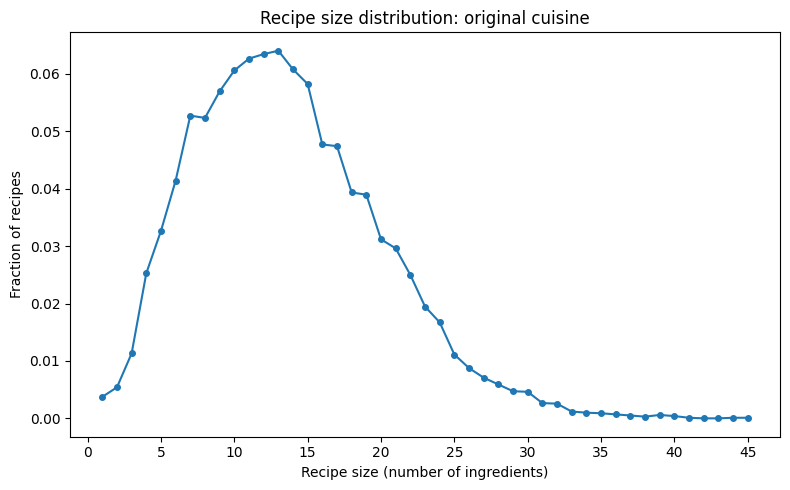

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(size_axis, orig_dist, color='tab:blue', marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel('Recipe size (number of ingredients)')
ax.set_ylabel('Fraction of recipes')
ax.set_title('Recipe size distribution: original cuisine')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Q2_original_recipe_size_distribution.png'), dpi=300)
plt.show()

In [3]:
def replica_cuisine(sizes, pool, rng):
    return [rng.choice(pool, size=s, replace=False).tolist() for s in sizes]

random_sets_a = [replica_cuisine(sizes, pool, rng) for _ in range(N_SETS)]

for i, cuisine in enumerate(random_sets_a, 1):
    rs = np.array([len(r) for r in cuisine])
    assert len(cuisine) == N and (rs == sizes).all()
    assert all(len(set(r)) == len(r) for r in cuisine)
print('10 random sets created; recipe sizes identical to the original in every set.')

10 random sets created; recipe sizes identical to the original in every set.


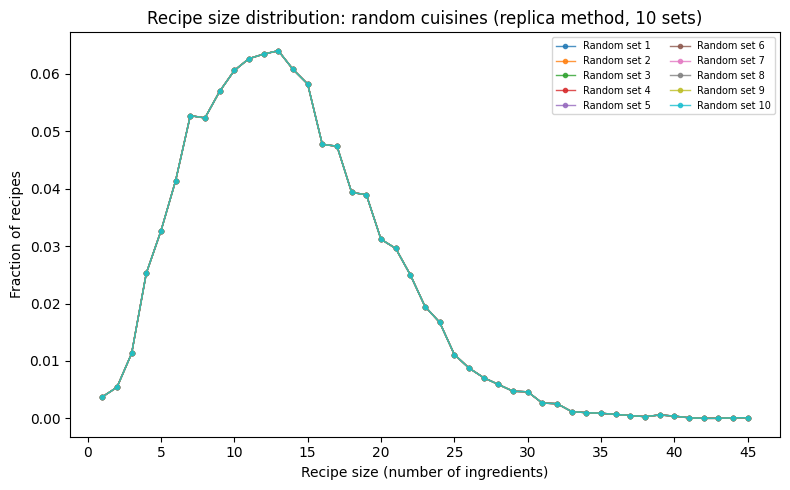

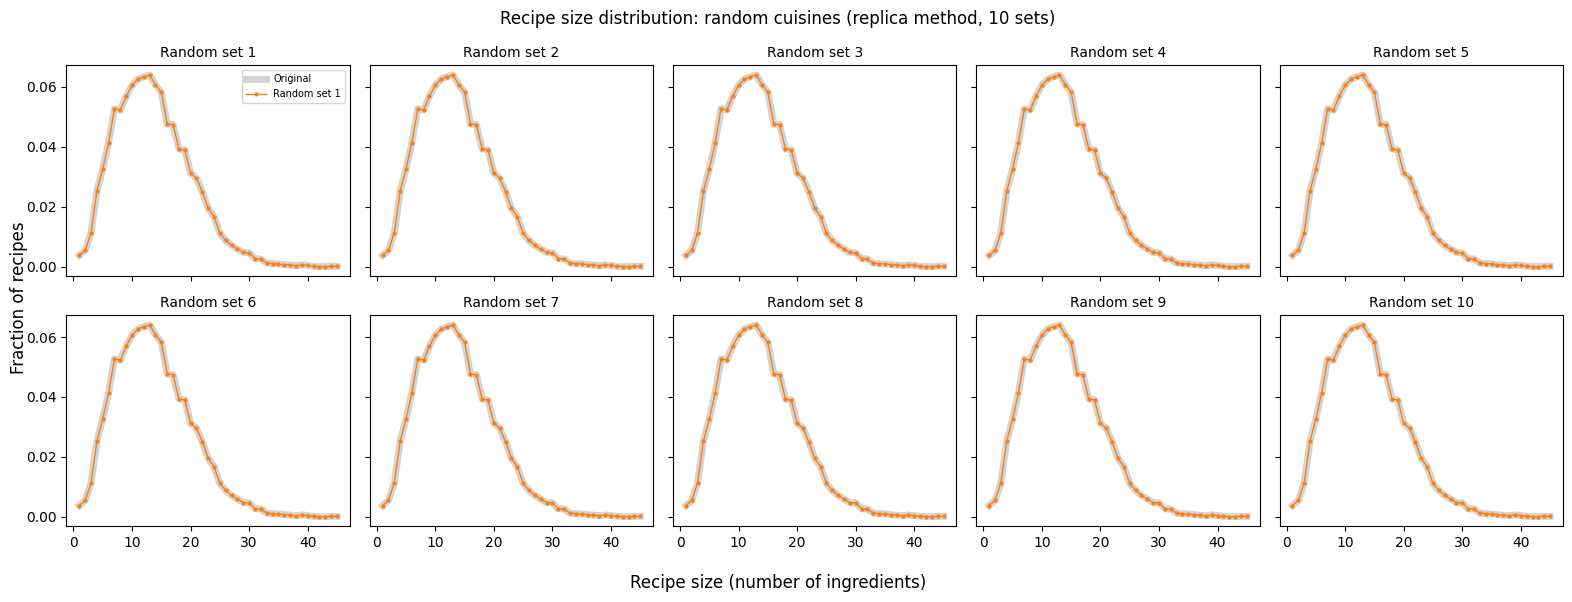

In [4]:
dist_a = np.array([size_distribution(np.array([len(r) for r in c])) for c in random_sets_a])  # 10 x sizes

fig, ax = plt.subplots(figsize=(8, 5))
for i, d in enumerate(dist_a, 1):
    ax.plot(size_axis, d, marker='o', markersize=3, linewidth=1, alpha=0.8, label=f'Random set {i}')
ax.set_xlabel('Recipe size (number of ingredients)')
ax.set_ylabel('Fraction of recipes')
ax.set_title('Recipe size distribution: random cuisines (replica method, 10 sets)')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Q2a_random_recipe_size_distribution_overlapped.png'), dpi=300)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True, sharey=True)
for i, (ax, d) in enumerate(zip(axes.ravel(), dist_a), 1):
    ax.plot(size_axis, orig_dist, color='lightgray', linewidth=5, label='Original')
    ax.plot(size_axis, d, color='tab:orange', marker='o', markersize=2, linewidth=1, label=f'Random set {i}')
    ax.set_title(f'Random set {i}', fontsize=10)
    ax.set_xticks(np.arange(0, sizes.max() + 1, 10))
fig.supxlabel('Recipe size (number of ingredients)')
fig.supylabel('Fraction of recipes')
fig.suptitle('Recipe size distribution: random cuisines (replica method, 10 sets)')
axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Q2a_random_recipe_size_distribution_panels.png'), dpi=300)
plt.show()

## Q2(b): Size-controlled cuisine using the inverse transformation

**Strategy (inverse transform sampling):**
1. Compute the empirical probability of each recipe size *s* in the original cuisine, P(s), and its cumulative distribution F(s) = P(size ≤ s).
2. Draw a uniform random number *u* ~ U(0, 1).
3. Map it through the inverse CDF: the recipe size is the smallest *s* with F(s) ≥ *u*, i.e. F⁻¹(u). Sizes drawn this way follow the original size distribution.
4. Create a random recipe of that size by sampling distinct ingredients uniformly from the pool.
5. Repeat for **10 × N = 100,000** recipes (10 times the original cuisine).

In [5]:
counts = np.bincount(sizes, minlength=sizes.max() + 1)[1:]
P = counts / counts.sum()
F = np.cumsum(P)
F[-1] = 1.0

def inverse_transform_sizes(n, rng):
    u = rng.random(n)
    idx = np.searchsorted(F, u, side='left')
    return size_axis[idx]

N_RANDOM = 10 * N
sizes_b = inverse_transform_sizes(N_RANDOM, rng)

random_cuisine_b = [rng.choice(pool, size=s, replace=False).tolist() for s in sizes_b]
assert len(random_cuisine_b) == 10 * N
assert all(len(set(r)) == len(r) for r in random_cuisine_b)
print('Random recipes created:', len(random_cuisine_b))
print('Mean size  original:', round(sizes.mean(), 3), '| random:', round(sizes_b.mean(), 3))

Random recipes created: 101680
Mean size  original: 13.646 | random: 13.672


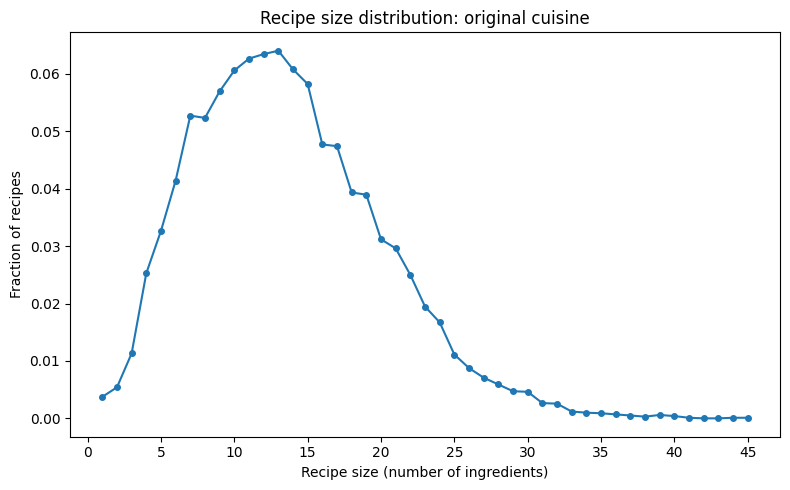

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(size_axis, orig_dist, color='tab:blue', marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel('Recipe size (number of ingredients)')
ax.set_ylabel('Fraction of recipes')
ax.set_title('Recipe size distribution: original cuisine')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
plt.tight_layout()
plt.show()

Max |P_random(s) - P_original(s)| = 0.0018


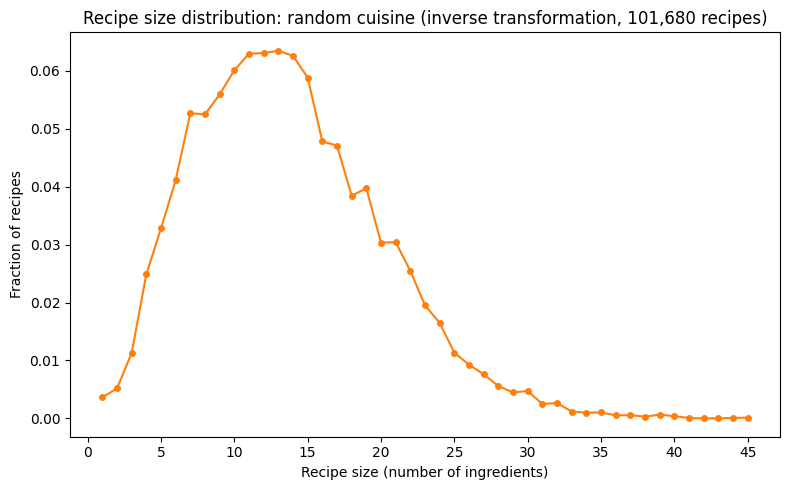

In [7]:
dist_b = size_distribution(sizes_b)
print('Max |P_random(s) - P_original(s)| =', round(np.abs(dist_b - orig_dist).max(), 4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(size_axis, dist_b, color='tab:orange', marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel('Recipe size (number of ingredients)')
ax.set_ylabel('Fraction of recipes')
ax.set_title(f'Recipe size distribution: random cuisine (inverse transformation, {N_RANDOM:,} recipes)')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Q2b_random_recipe_size_distribution.png'), dpi=300)
plt.show()